# Statistiques descriptives & Data Visualisation

Étapes 4 et 6 du projet : statistiques descriptives et visualisation des facteurs de réussite scolaire.

## 1. Chargement des données depuis HDFS et encodage

Même logique d'encodage que `analyse.ipynb`, pour rester cohérent avec le reste du pipeline.

In [1]:
import os
os.makedirs("figures", exist_ok=True)

import csv
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import when, col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

port = "9000"
spark = SparkSession.builder.appName("dataviz_student_performance").getOrCreate()
df = spark.read.csv(f"hdfs://localhost:{port}/projet/donnees/StudentPerformanceFactors_propre.csv", header=True, inferSchema=True)

In [2]:
df = df.withColumn("Implication_Parentale_num", when(df.Implication_Parentale == "Haut", 2).when(df.Implication_Parentale == "Moyen", 1).when(df.Implication_Parentale == "Bas", 0))
df = df.withColumn("Influence_Entourage_num", when(df.Influence_Entourage == "Negative", -1).when(df.Influence_Entourage == "Positif", 1).when(df.Influence_Entourage == "Neutre", 0))
df = df.withColumn("Acces_aux_Ressources_num", when(df.Acces_aux_Ressources == "Bas", 0).when(df.Acces_aux_Ressources == "Moyen", 1).when(df.Acces_aux_Ressources == "Haut", 2))
df = df.withColumn("Niveau_Motivation_num", when(df.Niveau_Motivation == "Bas", 0).when(df.Niveau_Motivation == "Moyen", 1).when(df.Niveau_Motivation == "Haut", 2))
df = df.withColumn("Qualite_Enseignant_num", when(df.Qualite_Enseignant == "Bas", 0).when(df.Qualite_Enseignant == "Moyen", 1).when(df.Qualite_Enseignant == "Haut", 2))
df = df.withColumn("Revenu_Famille_num", when(df.Revenu_Famille == "Bas", 0).when(df.Revenu_Famille == "Moyen", 1).when(df.Revenu_Famille == "Haut", 2))
df = df.withColumn("Distance_Maison_num", when(df.Distance_Maison == "Proche", 0).when(df.Distance_Maison == "Moderee", 1).when(df.Distance_Maison == "Loin", 2))
df = df.withColumn("Niveau_Education_Parents_num", when(df.Niveau_Education_Parents == "Lycee", 0).when(df.Niveau_Education_Parents == "Licence", 1).when(df.Niveau_Education_Parents == "Master", 2))
df = df.withColumn("Activites_Extrascolaires_num", when(df.Activites_Extrascolaires == "Oui", 1).when(df.Activites_Extrascolaires == "Non", 0))
df = df.withColumn("Troubles_Apprentissage_num", when(df.Troubles_Apprentissage == "Oui", 1).when(df.Troubles_Apprentissage == "Non", 0))
df = df.withColumn("Acces_Internet_num", when(df.Acces_Internet == "Oui", 1).when(df.Acces_Internet == "Non", 0))
df = df.withColumn("Type_Ecole_num", when(df.Type_Ecole == "Privee", 1).when(df.Type_Ecole == "Publique", 0))
df = df.withColumn("Genre_num", when(df.Genre == "Femme", 1).when(df.Genre == "Homme", 0))
df = df.dropDuplicates()

colonnes_num = [
    "Heures_Etudiees", "Presence", "Heures_Sommeil", "Scores_Precedents", "Sessions_Tutorat",
    "Activite_Physique", "Implication_Parentale_num", "Influence_Entourage_num", "Acces_aux_Ressources_num",
    "Niveau_Motivation_num", "Qualite_Enseignant_num", "Revenu_Famille_num", "Distance_Maison_num",
    "Niveau_Education_Parents_num", "Activites_Extrascolaires_num", "Troubles_Apprentissage_num",
    "Acces_Internet_num", "Type_Ecole_num", "Genre_num",
]

## 2. Charte graphique

Palette cohérente pour tous les graphiques (couleurs accessibles daltonisme, sens catégoriel / séquentiel / divergent respecté).

In [3]:
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"
BLUE = "#2a78d6"
AQUA = "#1baf7a"
RED = "#e34948"
SEQ_BLUE = ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95"]

plt.rcParams.update({
    "font.family": "Segoe UI",
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 12, "figure.dpi": 150,
})

def style_ax(ax):
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color(GRID)
    ax.grid(axis="y", zorder=0)
    ax.set_axisbelow(True)

## 3. Statistiques descriptives

Calculées entièrement côté Spark (agrégations `mean`/`stddev`/`min`/`max`), puis exportées en CSV.

In [4]:
stat_cols = colonnes_num + ["Score_Examen"]

agg_exprs = []
for c in stat_cols:
    agg_exprs += [
        F.mean(c).alias(f"{c}__mean"),
        F.stddev(c).alias(f"{c}__stddev"),
        F.min(c).alias(f"{c}__min"),
        F.max(c).alias(f"{c}__max"),
    ]
agg_row = df.agg(*agg_exprs).collect()[0]

desc_rows = []
for c in stat_cols:
    desc_rows.append({
        "Variable": c,
        "Moyenne": round(agg_row[f"{c}__mean"], 2),
        "Ecart-type": round(agg_row[f"{c}__stddev"], 2),
        "Min": agg_row[f"{c}__min"],
        "Max": agg_row[f"{c}__max"],
    })

with open("figures/statistiques_descriptives.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["Variable", "Moyenne", "Ecart-type", "Min", "Max"])
    writer.writeheader()
    writer.writerows(desc_rows)

desc_rows

[{'Variable': 'Heures_Etudiees',
  'Moyenne': 19.98,
  'Ecart-type': 5.99,
  'Min': 1,
  'Max': 44},
 {'Variable': 'Presence',
  'Moyenne': 80.02,
  'Ecart-type': 11.55,
  'Min': 60,
  'Max': 100},
 {'Variable': 'Heures_Sommeil',
  'Moyenne': 7.03,
  'Ecart-type': 1.47,
  'Min': 4,
  'Max': 10},
 {'Variable': 'Scores_Precedents',
  'Moyenne': 75.07,
  'Ecart-type': 14.4,
  'Min': 50,
  'Max': 100},
 {'Variable': 'Sessions_Tutorat',
  'Moyenne': 1.5,
  'Ecart-type': 1.23,
  'Min': 0,
  'Max': 8},
 {'Variable': 'Activite_Physique',
  'Moyenne': 2.97,
  'Ecart-type': 1.03,
  'Min': 0,
  'Max': 6},
 {'Variable': 'Implication_Parentale_num',
  'Moyenne': 1.09,
  'Ecart-type': 0.7,
  'Min': 0,
  'Max': 2},
 {'Variable': 'Influence_Entourage_num',
  'Moyenne': 0.19,
  'Ecart-type': 0.76,
  'Min': -1,
  'Max': 1},
 {'Variable': 'Acces_aux_Ressources_num',
  'Moyenne': 1.1,
  'Ecart-type': 0.7,
  'Min': 0,
  'Max': 2},
 {'Variable': 'Niveau_Motivation_num',
  'Moyenne': 0.91,
  'Ecart-type': 0.

## 4. Rapatriement des données pour la visualisation

Comme pour la partie Machine Learning, on rapatrie les colonnes nécessaires via `.collect()` une fois les agrégations lourdes faites côté Spark (tableaux numpy, pas pandas).

In [5]:
rows = df.select(colonnes_num + ["Score_Examen"]).collect()
data = {c: np.array([r[c] for r in rows]) for c in colonnes_num + ["Score_Examen"]}
len(rows)

6378

## 5. Data Viz

### 5.1 Distribution du score d'examen

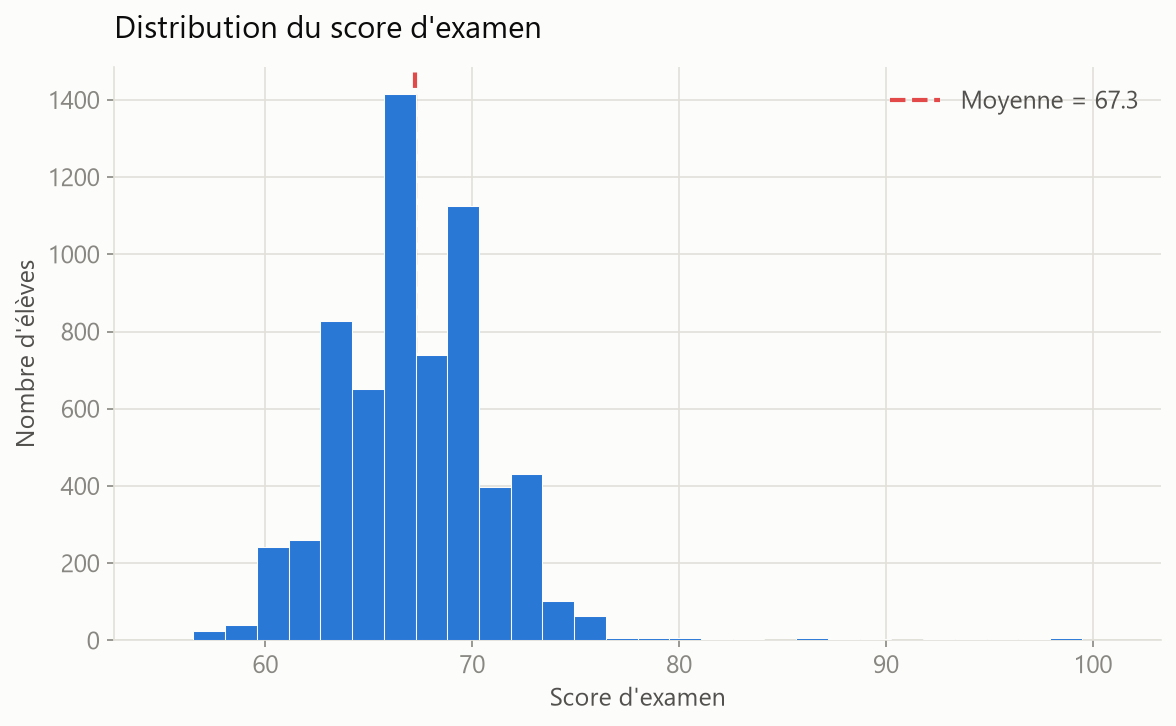

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data["Score_Examen"], bins=30, color=BLUE, edgecolor=SURFACE, linewidth=0.5, zorder=3)
ax.axvline(data["Score_Examen"].mean(), color=RED, linewidth=2, linestyle="--", label=f"Moyenne = {data['Score_Examen'].mean():.1f}")
ax.set_title("Distribution du score d'examen", fontsize=15, color=INK, loc="left", pad=14)
ax.set_xlabel("Score d'examen")
ax.set_ylabel("Nombre d'élèves")
style_ax(ax)
ax.legend(frameon=False, labelcolor=INK_SECONDARY)
fig.tight_layout()
fig.savefig("figures/01_distribution_score.png", facecolor=SURFACE)
plt.show()

### 5.2 Matrice de corrélation

Palette divergente (bleu = corrélation positive, rouge = corrélation négative) car le coefficient varie entre -1 et 1.

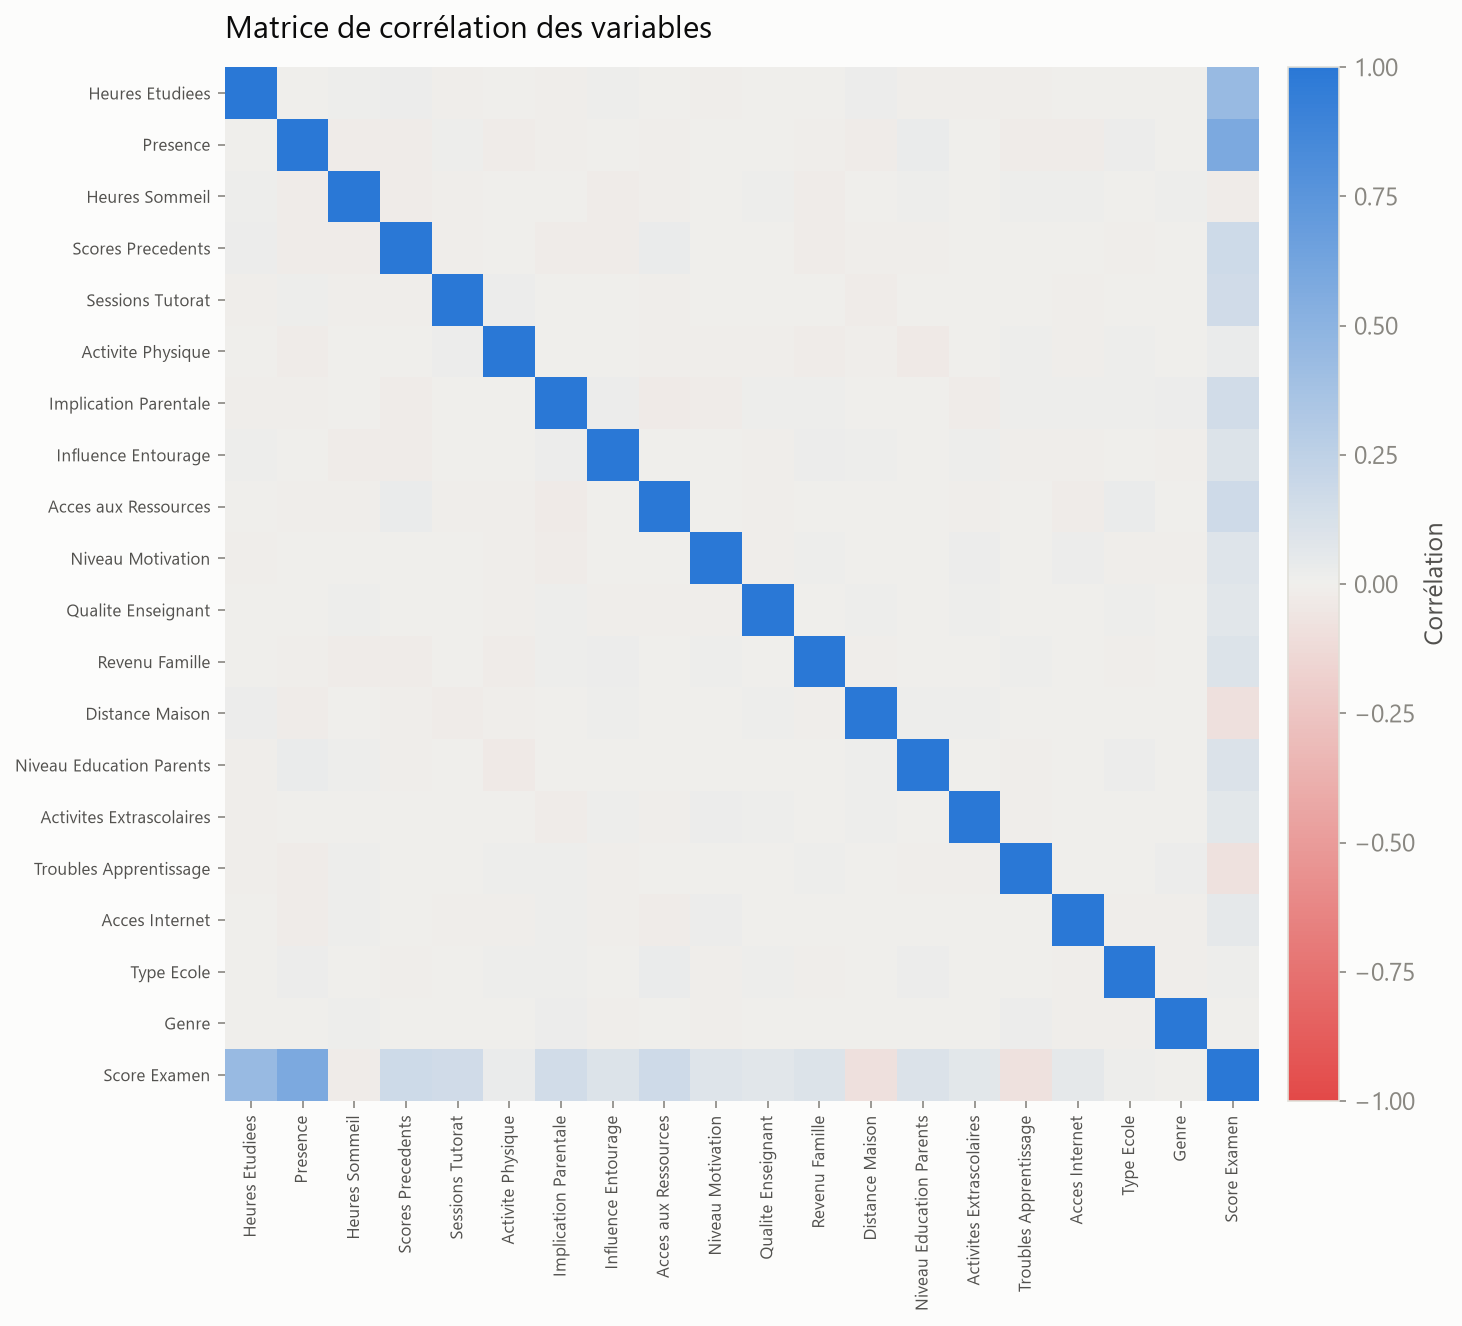

In [7]:
stat_cols = colonnes_num + ["Score_Examen"]
assembler = VectorAssembler(inputCols=stat_cols, outputCol="features")
vector_df = assembler.transform(df.select(stat_cols)).select("features")
corr_matrix = Correlation.corr(vector_df, "features").collect()[0][0]
corr_values = corr_matrix.toArray()

fig, ax = plt.subplots(figsize=(11, 9))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("diverging", ["#e34948", "#f0efec", "#2a78d6"])
im = ax.imshow(corr_values, cmap=cmap, vmin=-1, vmax=1)
labels = [c.replace("_num", "").replace("_", " ") for c in stat_cols]
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=8, color=INK_SECONDARY)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8, color=INK_SECONDARY)
ax.spines[:].set_visible(False)
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.ax.tick_params(colors=INK_MUTED)
cbar.set_label("Corrélation", color=INK_SECONDARY)
ax.set_title("Matrice de corrélation des variables", fontsize=15, color=INK, loc="left", pad=14)
fig.tight_layout()
fig.savefig("figures/02_matrice_correlation.png", facecolor=SURFACE)
plt.show()

### 5.3 Variables les plus corrélées au score

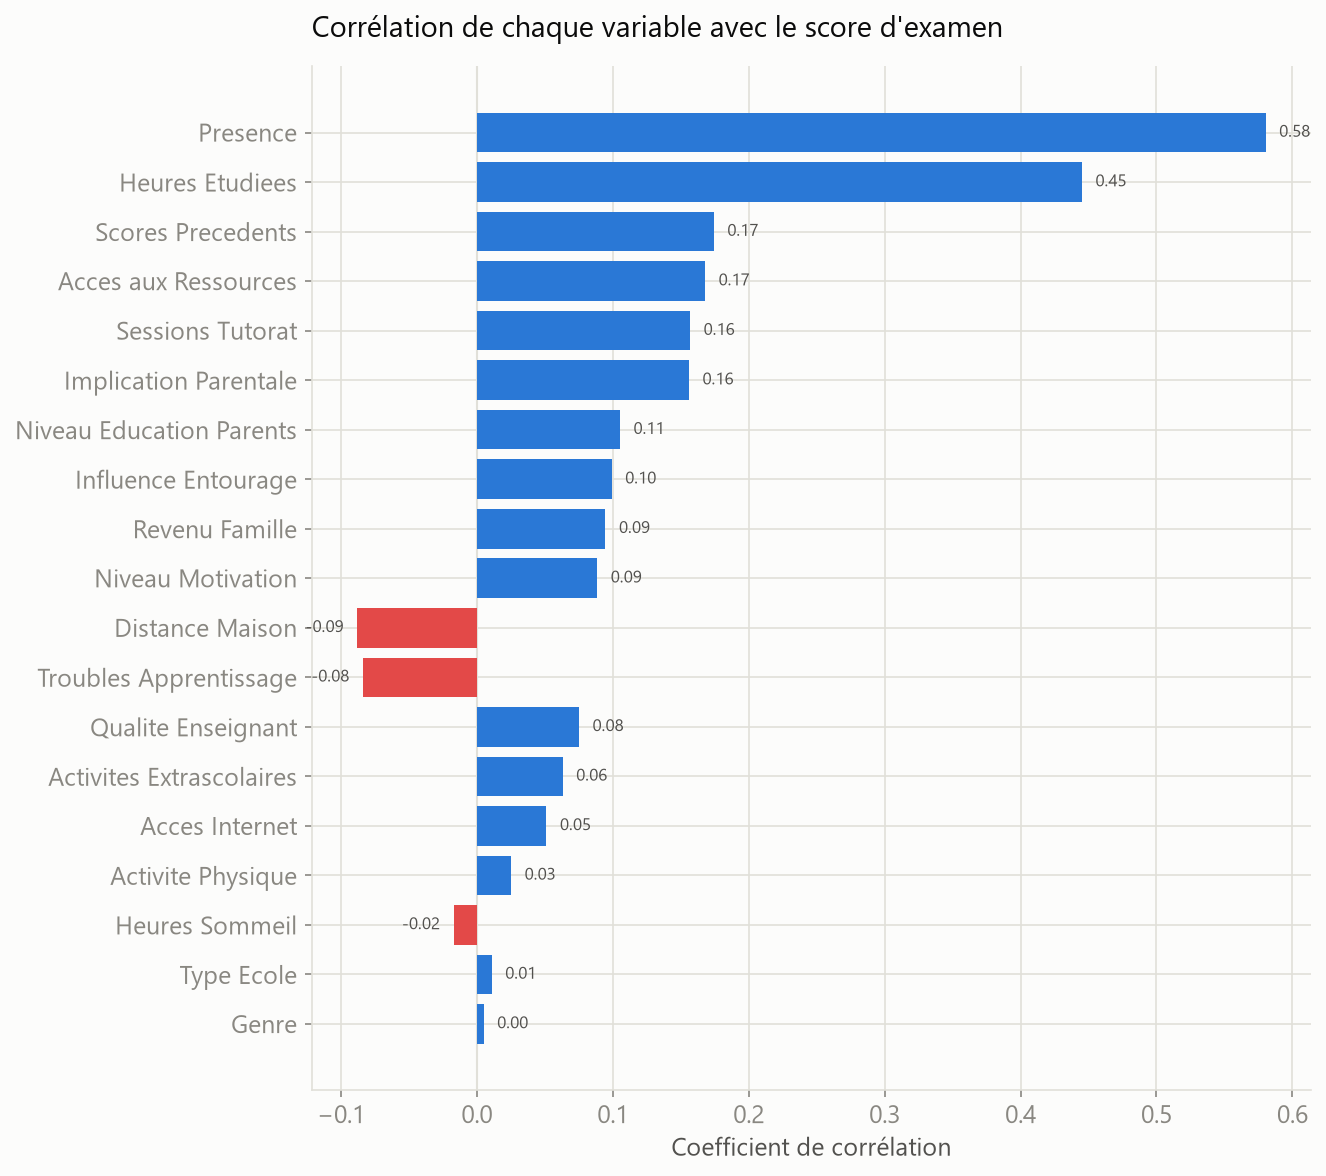

In [8]:
score_idx = stat_cols.index("Score_Examen")
pairs = [(stat_cols[i], corr_values[score_idx, i]) for i in range(len(stat_cols)) if i != score_idx]
pairs.sort(key=lambda p: abs(p[1]))

labels_sorted = [c.replace("_num", "").replace("_", " ") for c, _ in pairs]
values_sorted = [v for _, v in pairs]
colors = [BLUE if v >= 0 else RED for v in values_sorted]

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(labels_sorted, values_sorted, color=colors, zorder=3)
ax.axvline(0, color=GRID, linewidth=1)
ax.set_title("Corrélation de chaque variable avec le score d'examen", fontsize=14, color=INK, loc="left", pad=14)
ax.set_xlabel("Coefficient de corrélation")
style_ax(ax)
ax.grid(axis="x", zorder=0)
for bar, v in zip(bars, values_sorted):
    ax.text(v + (0.01 if v >= 0 else -0.01), bar.get_y() + bar.get_height() / 2, f"{v:.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8, color=INK_SECONDARY)
fig.tight_layout()
fig.savefig("figures/03_top_correlations.png", facecolor=SURFACE)
plt.show()

### 5.4 Relations avec les deux facteurs les plus corrélés

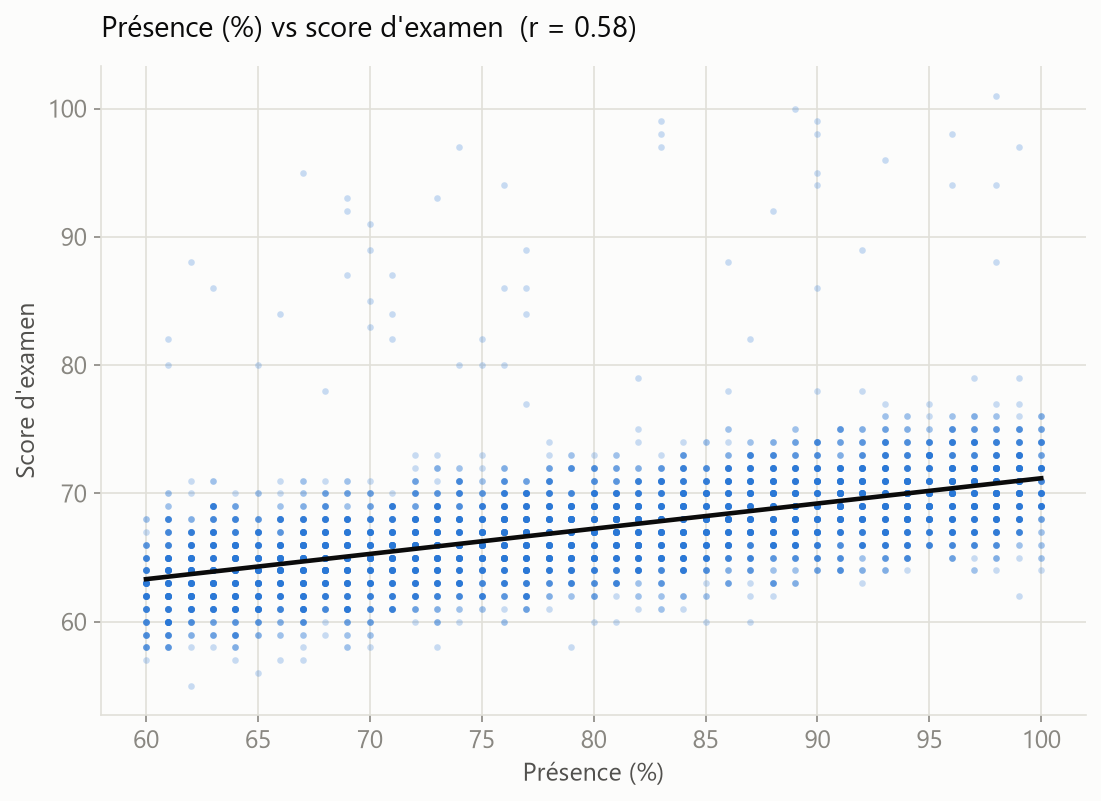

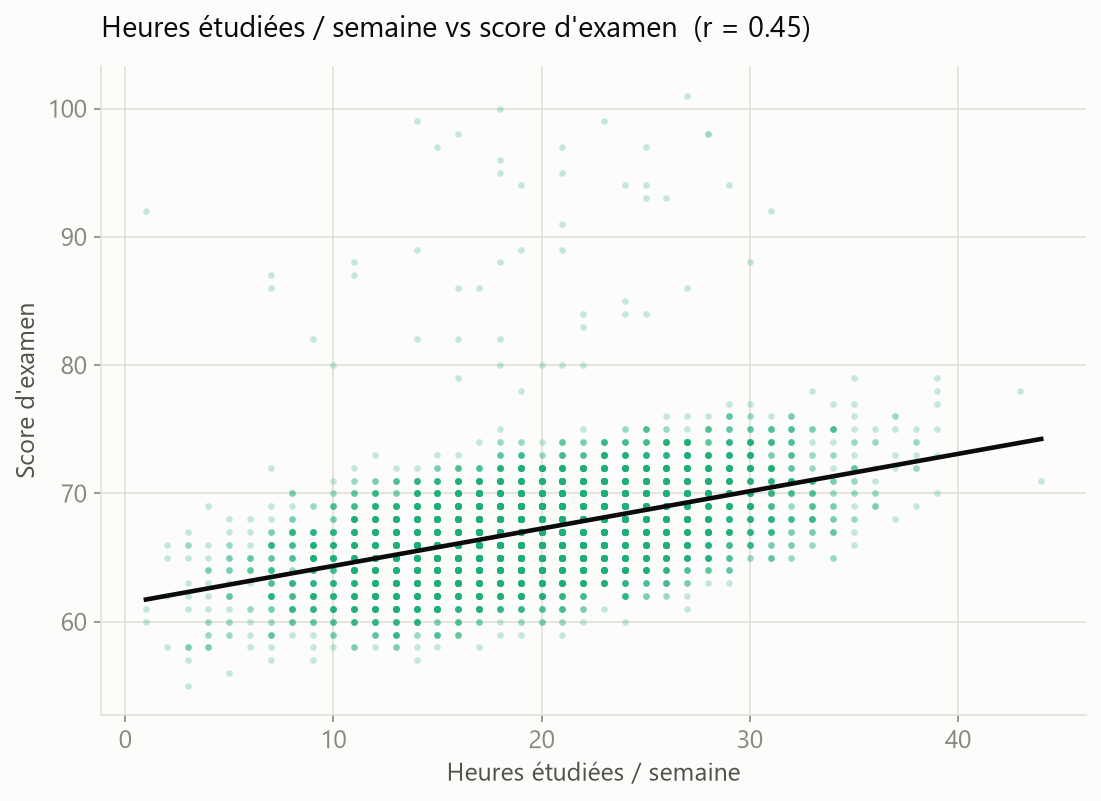

In [9]:
def scatter_relation(xcol, xlabel, fname, color):
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.scatter(data[xcol], data["Score_Examen"], s=10, alpha=0.25, color=color, linewidths=0, zorder=3)
    z = np.polyfit(data[xcol], data["Score_Examen"], 1)
    xs = np.linspace(data[xcol].min(), data[xcol].max(), 100)
    ax.plot(xs, np.polyval(z, xs), color=INK, linewidth=2.2, zorder=4)
    r = np.corrcoef(data[xcol], data["Score_Examen"])[0, 1]
    ax.set_title(f"{xlabel} vs score d'examen  (r = {r:.2f})", fontsize=14, color=INK, loc="left", pad=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Score d'examen")
    style_ax(ax)
    fig.tight_layout()
    fig.savefig(f"figures/{fname}", facecolor=SURFACE)
    plt.show()

scatter_relation("Presence", "Présence (%)", "04_scatter_presence.png", BLUE)
scatter_relation("Heures_Etudiees", "Heures étudiées / semaine", "05_scatter_heures_etudiees.png", AQUA)

### 5.5 Score par catégorie ordonnée (motivation, accès aux ressources)

Rampe séquentielle bleue (clair → foncé) car les catégories sont ordonnées (Bas < Moyen < Haut).

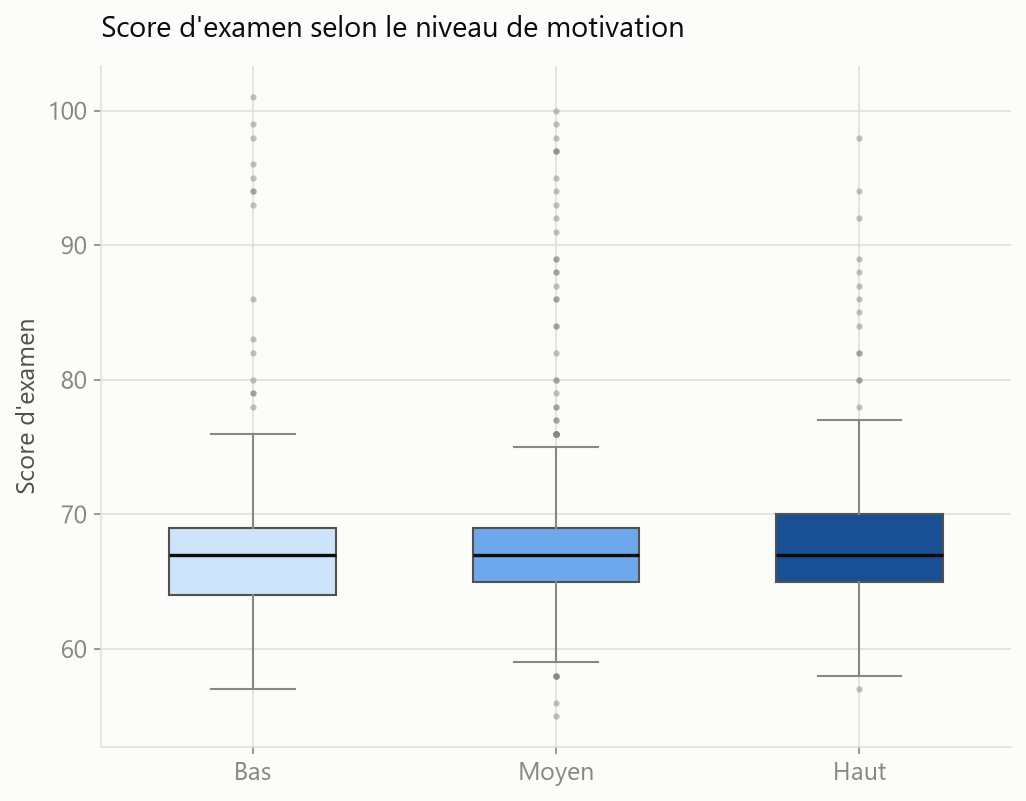

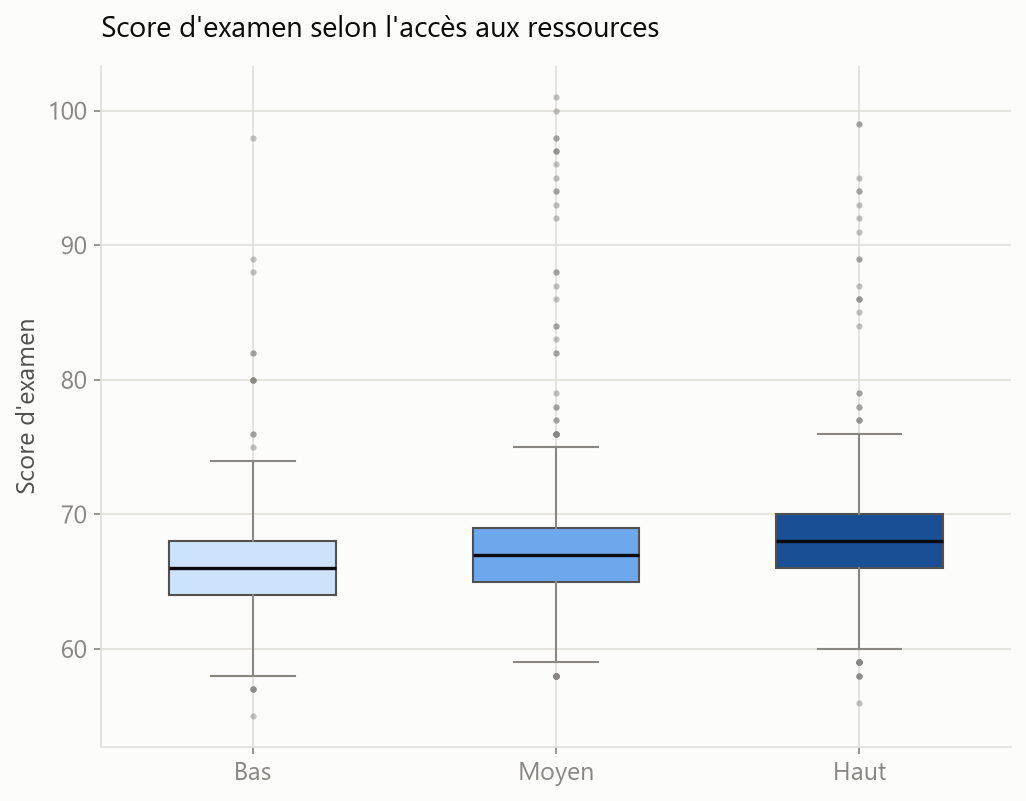

In [10]:
def boxplot_ordinal(order_map, title, fname, spark_col):
    order = list(order_map.keys())
    box_data = [data["Score_Examen"][data[spark_col] == order_map[o]] for o in order]
    fig, ax = plt.subplots(figsize=(7, 5.5))
    bp = ax.boxplot(box_data, patch_artist=True, tick_labels=order, widths=0.55,
                     medianprops=dict(color=INK, linewidth=1.6),
                     whiskerprops=dict(color=INK_MUTED), capprops=dict(color=INK_MUTED),
                     flierprops=dict(markerfacecolor=INK_MUTED, markeredgecolor="none", markersize=3, alpha=0.5))
    ramp = [SEQ_BLUE[i * (len(SEQ_BLUE) - 1) // max(len(order) - 1, 1)] for i in range(len(order))]
    for patch, c in zip(bp["boxes"], ramp):
        patch.set_facecolor(c)
        patch.set_edgecolor(INK_SECONDARY)
    ax.set_title(title, fontsize=14, color=INK, loc="left", pad=14)
    ax.set_ylabel("Score d'examen")
    style_ax(ax)
    fig.tight_layout()
    fig.savefig(f"figures/{fname}", facecolor=SURFACE)
    plt.show()

boxplot_ordinal({"Bas": 0, "Moyen": 1, "Haut": 2}, "Score d'examen selon le niveau de motivation", "06_box_motivation.png", "Niveau_Motivation_num")
boxplot_ordinal({"Bas": 0, "Moyen": 1, "Haut": 2}, "Score d'examen selon l'accès aux ressources", "07_box_ressources.png", "Acces_aux_Ressources_num")

### 5.6 Score par type d'école

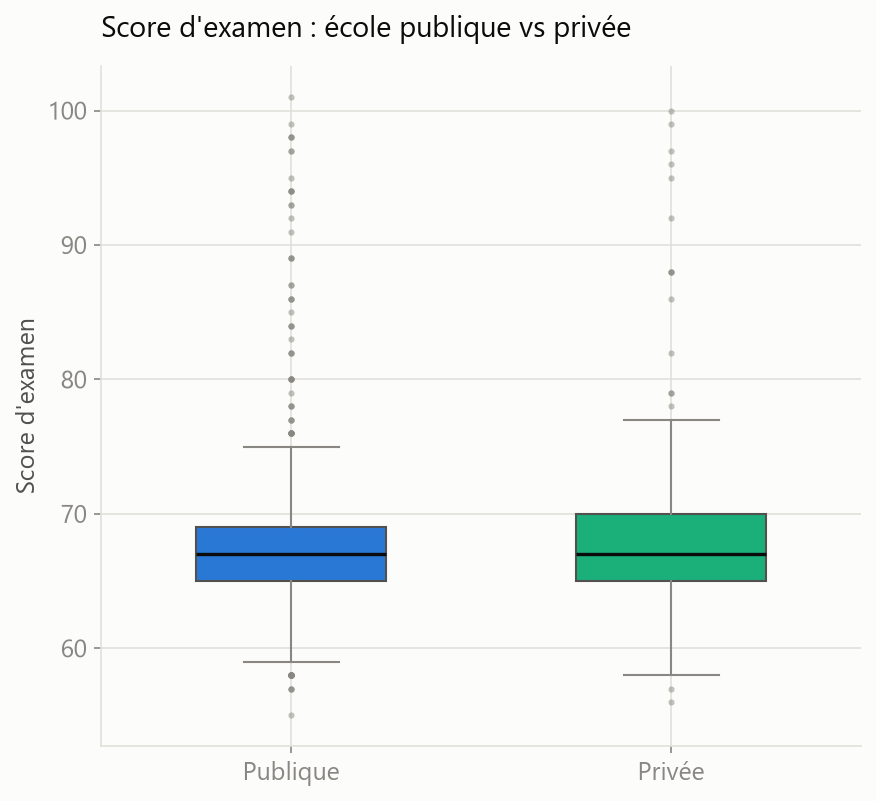

In [11]:
box_data = [data["Score_Examen"][data["Type_Ecole_num"] == 0], data["Score_Examen"][data["Type_Ecole_num"] == 1]]
fig, ax = plt.subplots(figsize=(6, 5.5))
bp = ax.boxplot(box_data, patch_artist=True, tick_labels=["Publique", "Privée"], widths=0.5,
                 medianprops=dict(color=INK, linewidth=1.6),
                 whiskerprops=dict(color=INK_MUTED), capprops=dict(color=INK_MUTED),
                 flierprops=dict(markerfacecolor=INK_MUTED, markeredgecolor="none", markersize=3, alpha=0.5))
for patch, c in zip(bp["boxes"], [BLUE, AQUA]):
    patch.set_facecolor(c)
    patch.set_edgecolor(INK_SECONDARY)
ax.set_title("Score d'examen : école publique vs privée", fontsize=14, color=INK, loc="left", pad=14)
ax.set_ylabel("Score d'examen")
style_ax(ax)
fig.tight_layout()
fig.savefig("figures/08_box_type_ecole.png", facecolor=SURFACE)
plt.show()

## 6. Conclusion

La présence en cours et le nombre d'heures étudiées sont de loin les facteurs les plus corrélés au score d'examen (r = 0.58 et r = 0.45). Les variables socio-économiques et catégorielles (motivation, type d'école, revenu familial) ont un effet individuel beaucoup plus faible sur ce dataset.